In [15]:
import pandas as pd
from pathlib import Path
from io import StringIO

results_dir = Path("../results")
result_file = results_dir / "experiment_results-1260.jsonl"

raw_result_df = pd.read_json(result_file, lines=True)
raw_result_df.head()

,timestamp,success,config,final_h,final_v,reasoning,bounce_locations,actual_distance_bounce_3,error,within_tolerance,time_taken,model,iterations_run,history
0,2025-04-25 22:43:39,False,"{'experiment': {'type': 'baseline_cot', 'visua...",12.30,25.0,"First, I calculated the time of flight for one...","[39.524999999998826, 110.65000000000803, 174.6...",174.650000,124.65,0.0,1.581406,NaN,NaN,NaN
1,2025-04-25 22:43:40,False,"{'experiment': {'type': 'baseline_cot', 'visua...",12.25,28.5,"To solve this problem, I first calculated the ...","[44.944500000000936, 125.82749999998859, 198.6...",198.645000,148.645,0.0,1.584037,NaN,NaN,NaN
2,2025-04-25 22:43:42,False,"{'experiment': {'type': 'baseline_cot', 'visua...",7.80,30.2,"First, I calculated the time of flight for the...","[37.96140000000062, 106.27379999999219, 169.70...",169.702964,119.702964,0.0,1.413879,NaN,NaN,NaN
3,2025-04-25 22:43:43,False,"{'experiment': {'type': 'baseline_cot', 'visua...",7.20,32.1,"First, I calculated the period of the sinusoid...","[38.16689999999977, -27.90402265661734, 27.131...",27.131875,22.868125,0.0,1.549707,NaN,NaN,NaN
4,2025-04-25 22:43:45,False,"{'experiment': {'type': 'baseline_cot', 'visua...",11.80,32.5,"First, I calculated the period of the sinusoid...","[50.27749999999894, 119.01172015281735, 64.420...",64.420278,14.420278,0.0,1.729173,NaN,NaN,NaN


In [41]:
config_df = pd.json_normalize(raw_result_df["config"])
result_df = pd.concat([raw_result_df, config_df], axis=1)
result_df = (
    result_df[result_df["actual_distance_bounce_3"].notna()]
    .drop(columns=["config"])
    .sort_values("timestamp")
)
result_df = result_df[
    [
        "timestamp",
        "success",
        "final_h",
        "final_v",
        "bounce_locations",
        "actual_distance_bounce_3",
        "error",
        "time_taken",
        "experiment.type",
        "experiment.target_distance",
        "experiment.target_bounce_number",
        "experiment.max_iterations",
        "llm.service",
        "llm.model_name",
        "llm.temperature",
        "ground.type",
        "ground.amplitude",
        "ground.frequency",
        "ground.difficulty",
        "ground.easy.amplitude",
        "ground.easy.frequency",
        "ground.hard.amplitudes",
        "ground.hard.frequencies",
    ]
].rename(
    columns={
        "timestamp": "Timestamp",
        "success": "Success",
        "final_h": "Final Horizontal Position",
        "final_v": "Final Vertical Position",
        "bounce_locations": "Bounce Locations",
        "actual_distance_bounce_3": "Actual Distance on Bounce 3",
        "error": "Error",
        "time_taken": "Time Taken",
        "experiment.type": "Experiment Type",
        "experiment.target_distance": "Target Distance",
        "experiment.target_bounce_number": "Target Bounce Number",
        "experiment.max_iterations": "Max Iterations",
        "llm.service": "LLM Service",
        "llm.model_name": "LLM Model Name",
        "llm.temperature": "LLM Temperature",
        "ground.type": "Ground Type",
        "ground.amplitude": "Ground Amplitude",
        "ground.frequency": "Ground Frequency",
        "ground.difficulty": "Ground Difficulty",
        "ground.easy.amplitude": "Easy Ground Amplitude",
        "ground.easy.frequency": "Easy Ground Frequency",
        "ground.hard.amplitudes": "Hard Ground Amplitudes",
        "ground.hard.frequencies": "Hard Ground Frequencies",
    }
)
result_df["Ground Type"] = result_df["Ground Type"].str.title()
result_df["Experiment Type"] = (
    result_df["Experiment Type"]
    .str.replace("baseline_cot", "Baseline CoT")
    .str.replace("simlm", "SimLM")
)
result_df["LLM Service"] = (
    result_df["LLM Service"].str.title().str.replace("Openai", "OpenAI")
)

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# remove top and right spines with rcParams
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

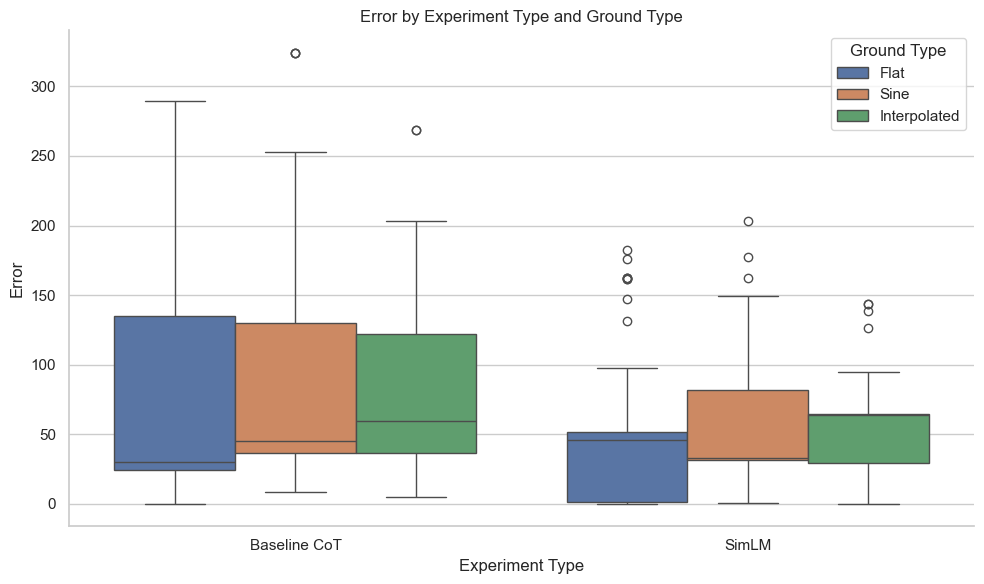

In [43]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=result_df,
    x="Experiment Type",
    y="Error",
    hue="Ground Type",
)
plt.title("Error by Experiment Type and Ground Type")
plt.xlabel("Experiment Type")
plt.ylabel("Error")
plt.legend(title="Ground Type")
plt.tight_layout()


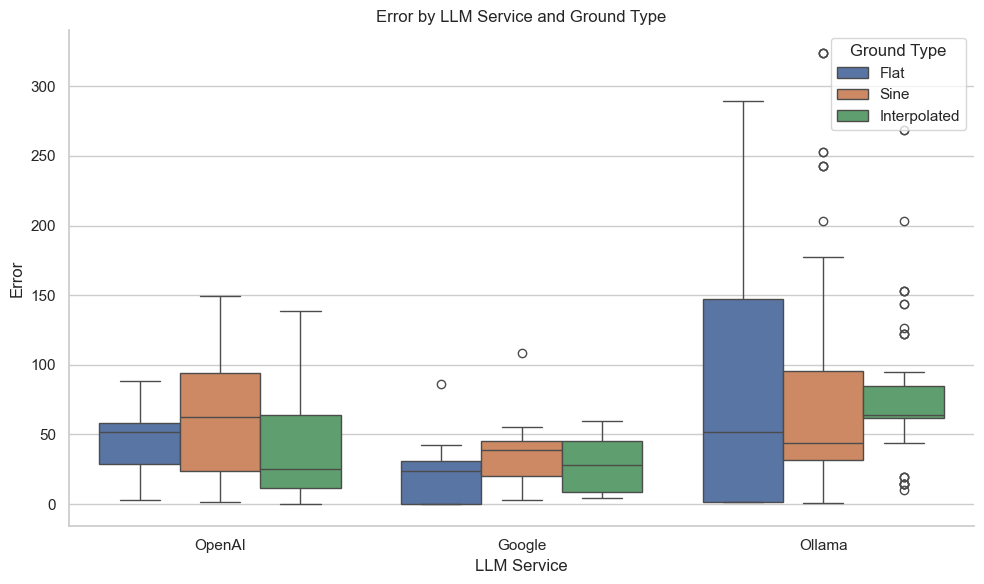

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=result_df,
    x="LLM Service",
    y="Error",
    hue="Ground Type",
)
plt.title("Error by LLM Service and Ground Type")
plt.xlabel("LLM Service")
plt.ylabel("Error")
plt.legend(title="Ground Type")
plt.tight_layout()